# 原始 attention 与原生载体审计

本报告检查逐 head 结构、正常轨迹趋势及有限两跳实例。没有训练检测器，没有机制检测 AUROC。

| split/task | 样本 | source | token/完整 token | 正常 token | 幻觉 token | 两跳实例 |
|---|---:|---:|---:|---:|---:|---:|
| test/ALL | 449 | 449 | 73994/73994 | 69400 | 4594 | 18 |
| test/QA | 149 | 149 | 30619/30619 | 28312 | 2307 | 6 |
| test/Summary | 150 | 150 | 18434/18434 | 17620 | 814 | 6 |
| test/Data2txt | 150 | 150 | 24941/24941 | 23468 | 1473 | 6 |
| train/ALL | 2497 | 2497 | 435840/435840 | 397847 | 37993 | 18 |
| train/QA | 822 | 822 | 185091/185091 | 162442 | 22649 | 6 |
| train/Summary | 793 | 793 | 101477/101477 | 96310 | 5167 | 6 |
| train/Data2txt | 882 | 882 | 149272/149272 | 139095 | 10177 | 6 |

先打开 `gallery.html` 看完整回答曲线、原始来源图和两跳实例。

`summary.json` 保留每个 layer/head 的趋势与 H−N 差异及来源区间；`head_pairs_*.npz` 按实际 head ID 保存同一载体、严格递增层序的配对结果与可用来源数。

正常 token 的趋势与完全正常回答的趋势分别报告。prompt 占比下降也可能来自可见 history 数量增长，需同时检查减去均匀来源占比后的对照趋势。

两跳实例的真实残差、全部 head code、MLP 写入及带符号读出在原 NPZ 的 `relay_*` 字段。它们显示运算与结构，并未验证某项事实被正确传递，也不把模长当功能贡献。


population_test_QA.png


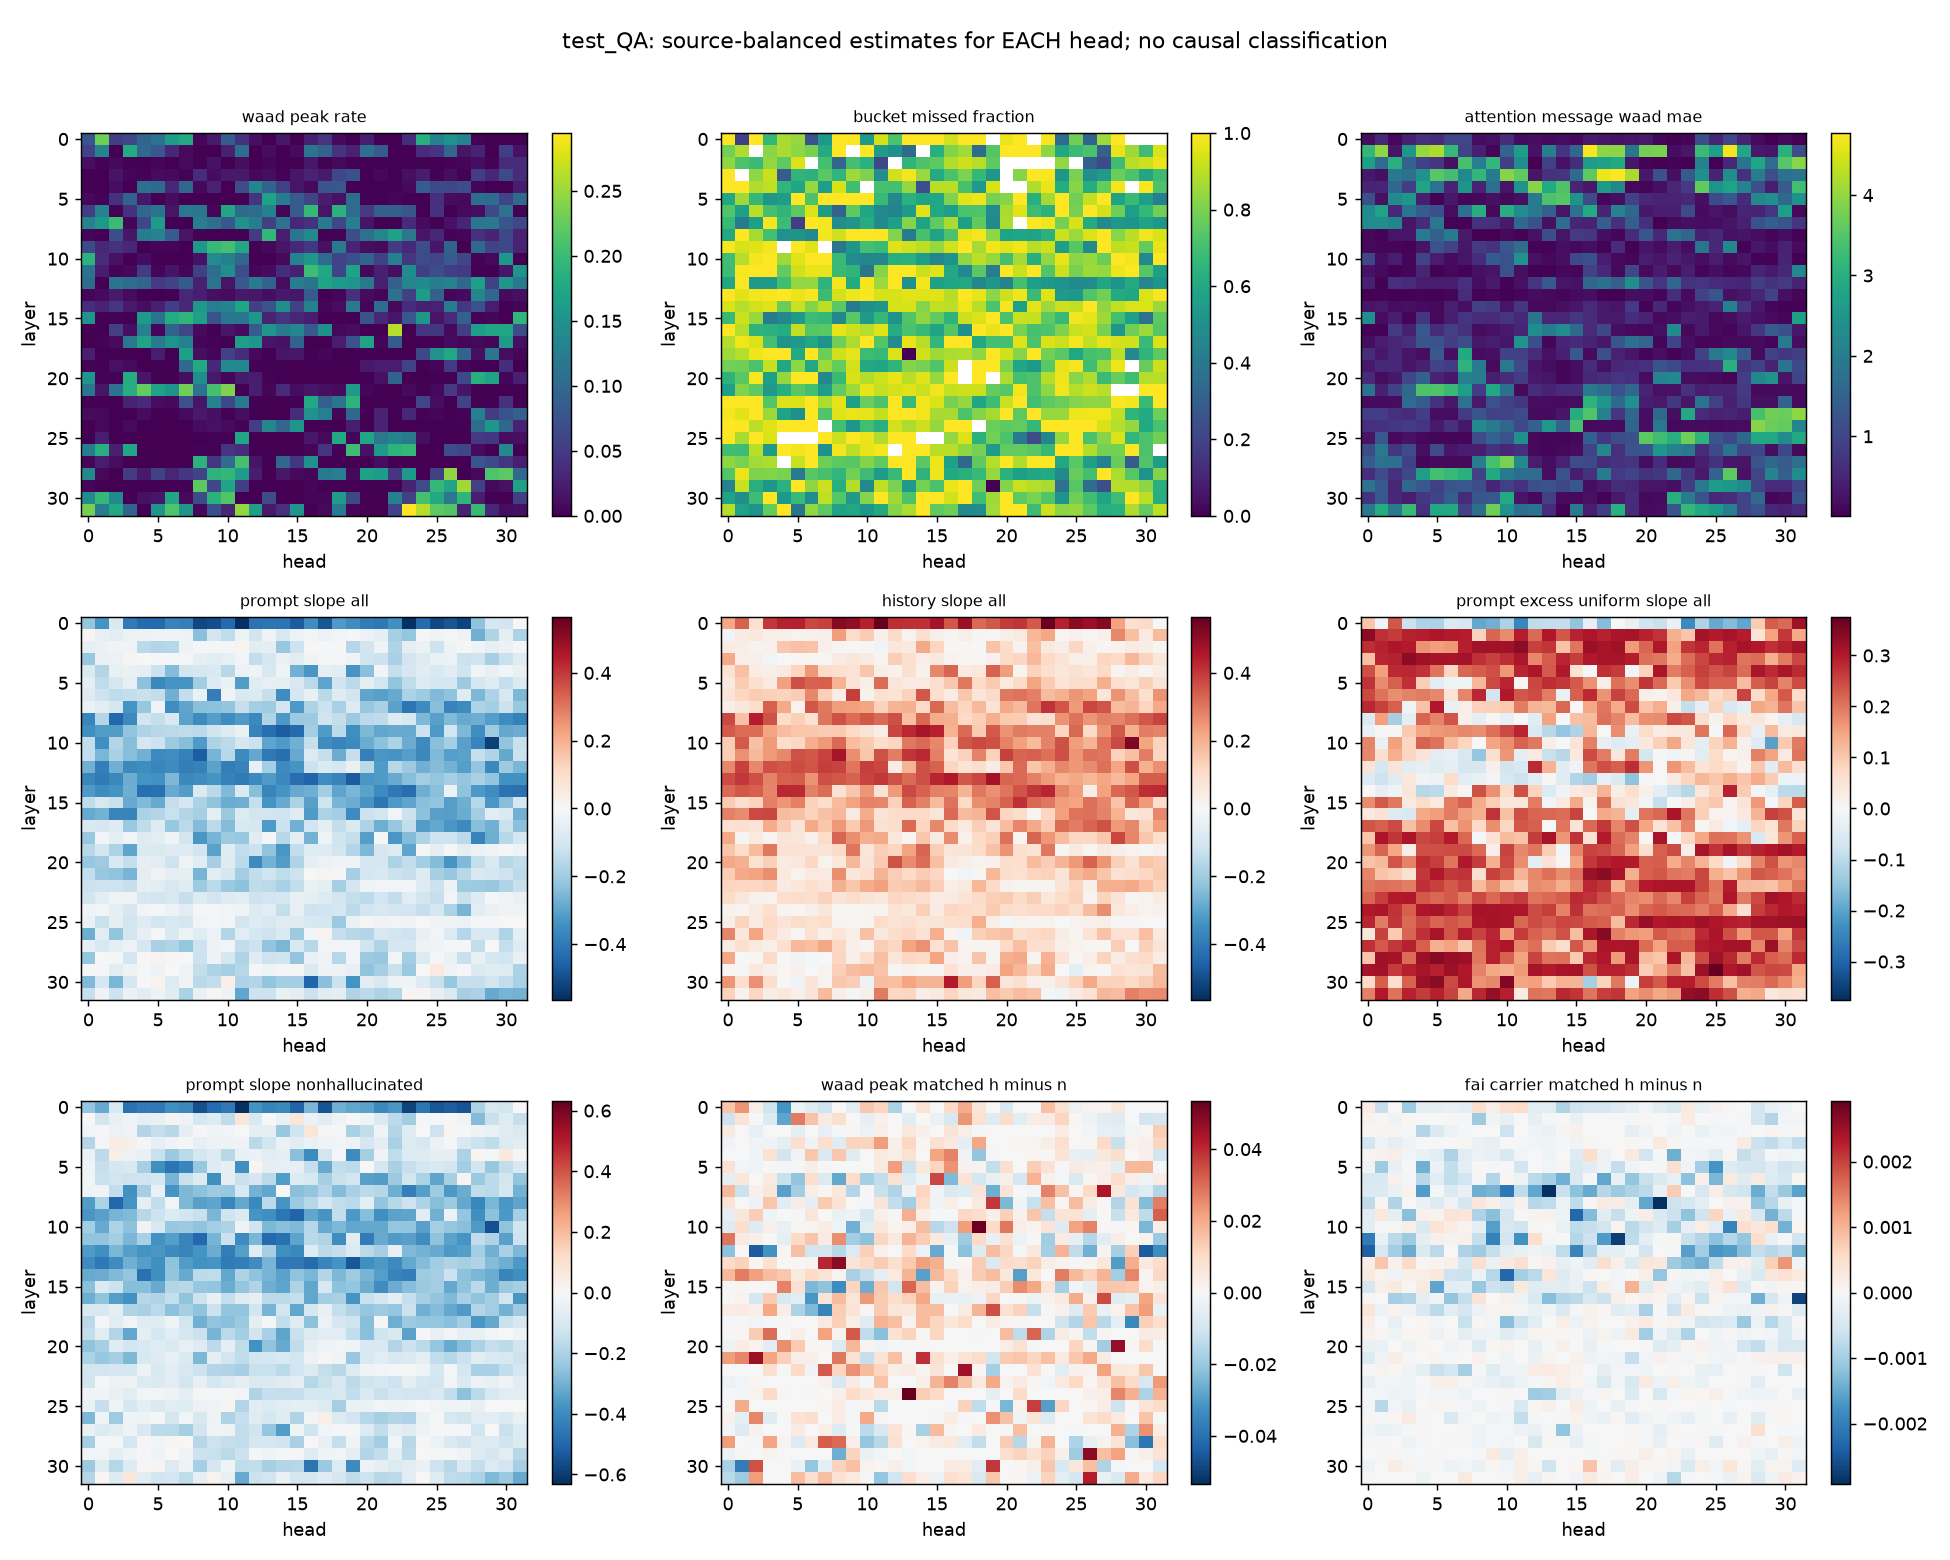

head_pairs_test_QA.png


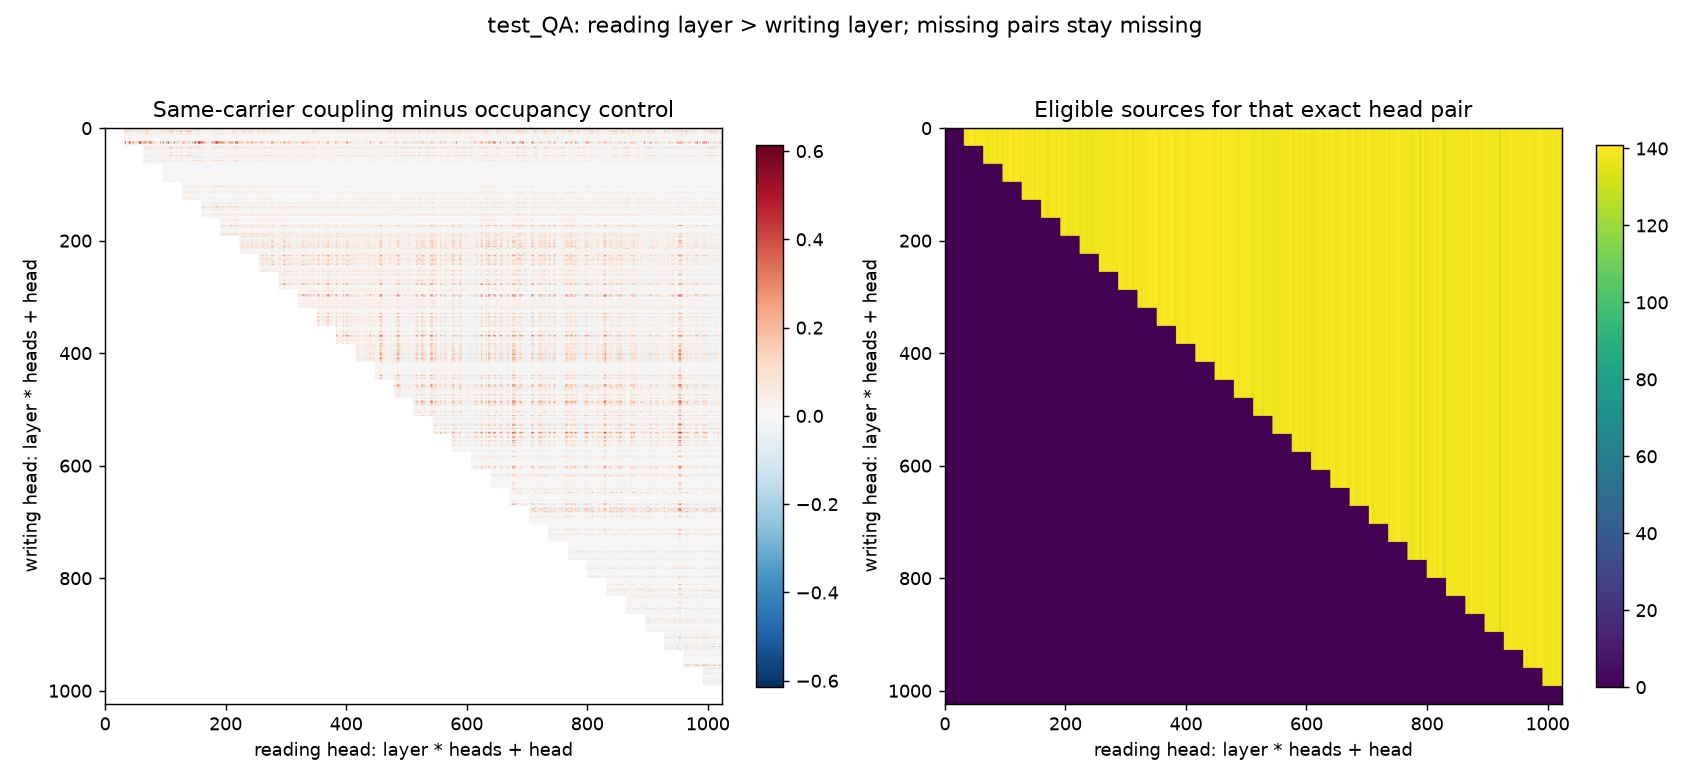

population_test_Summary.png


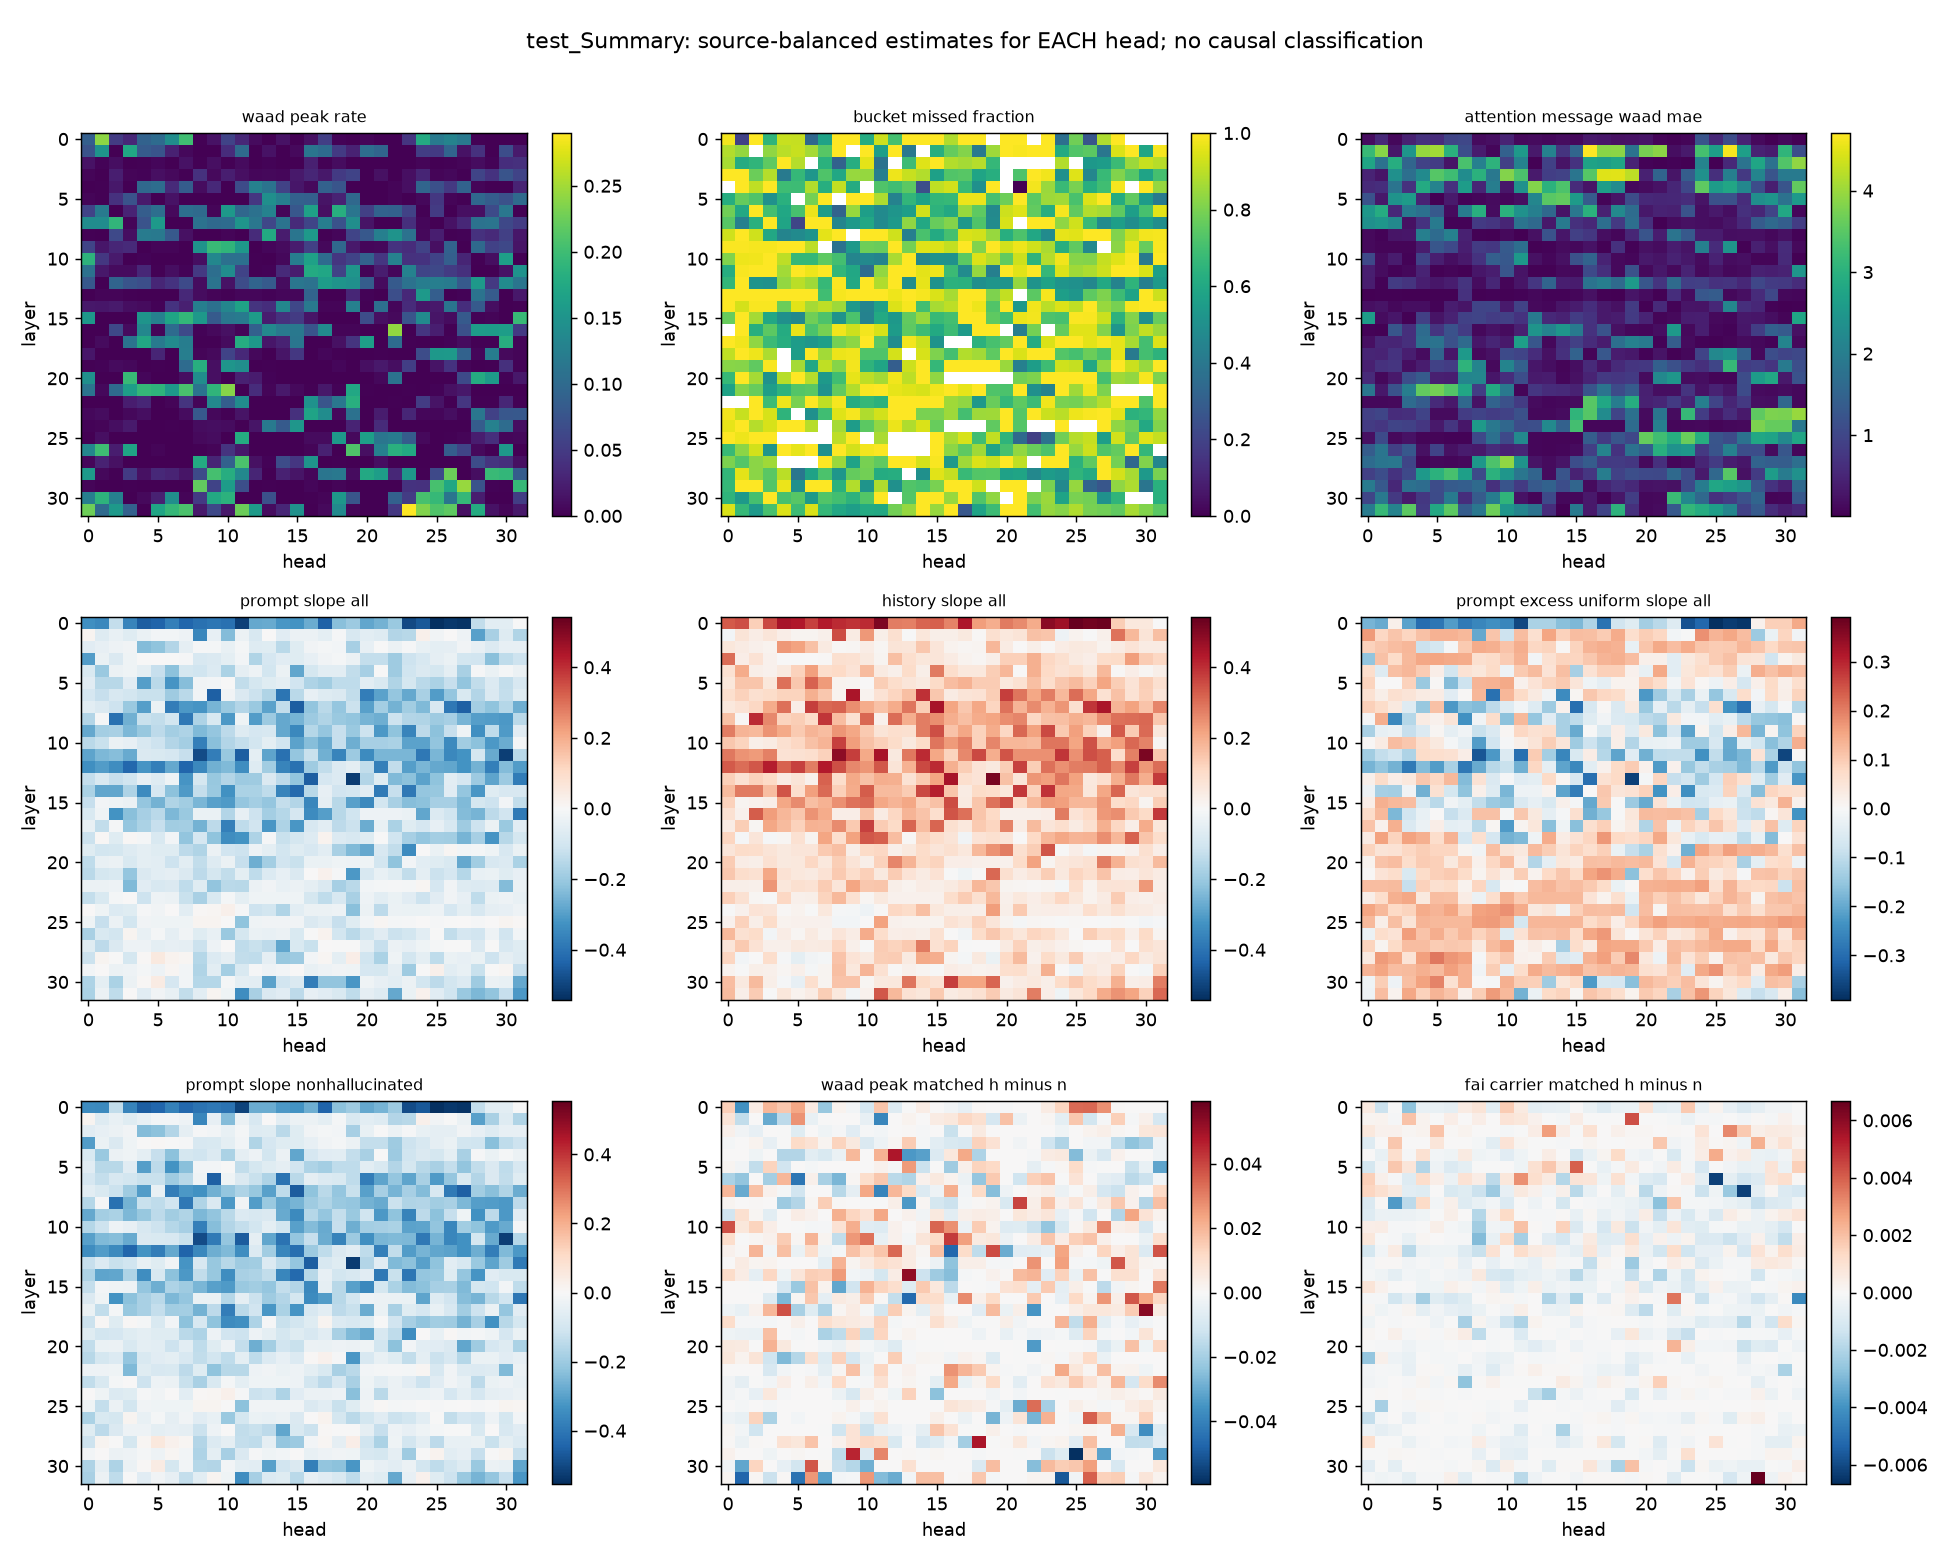

population_test_Data2txt.png


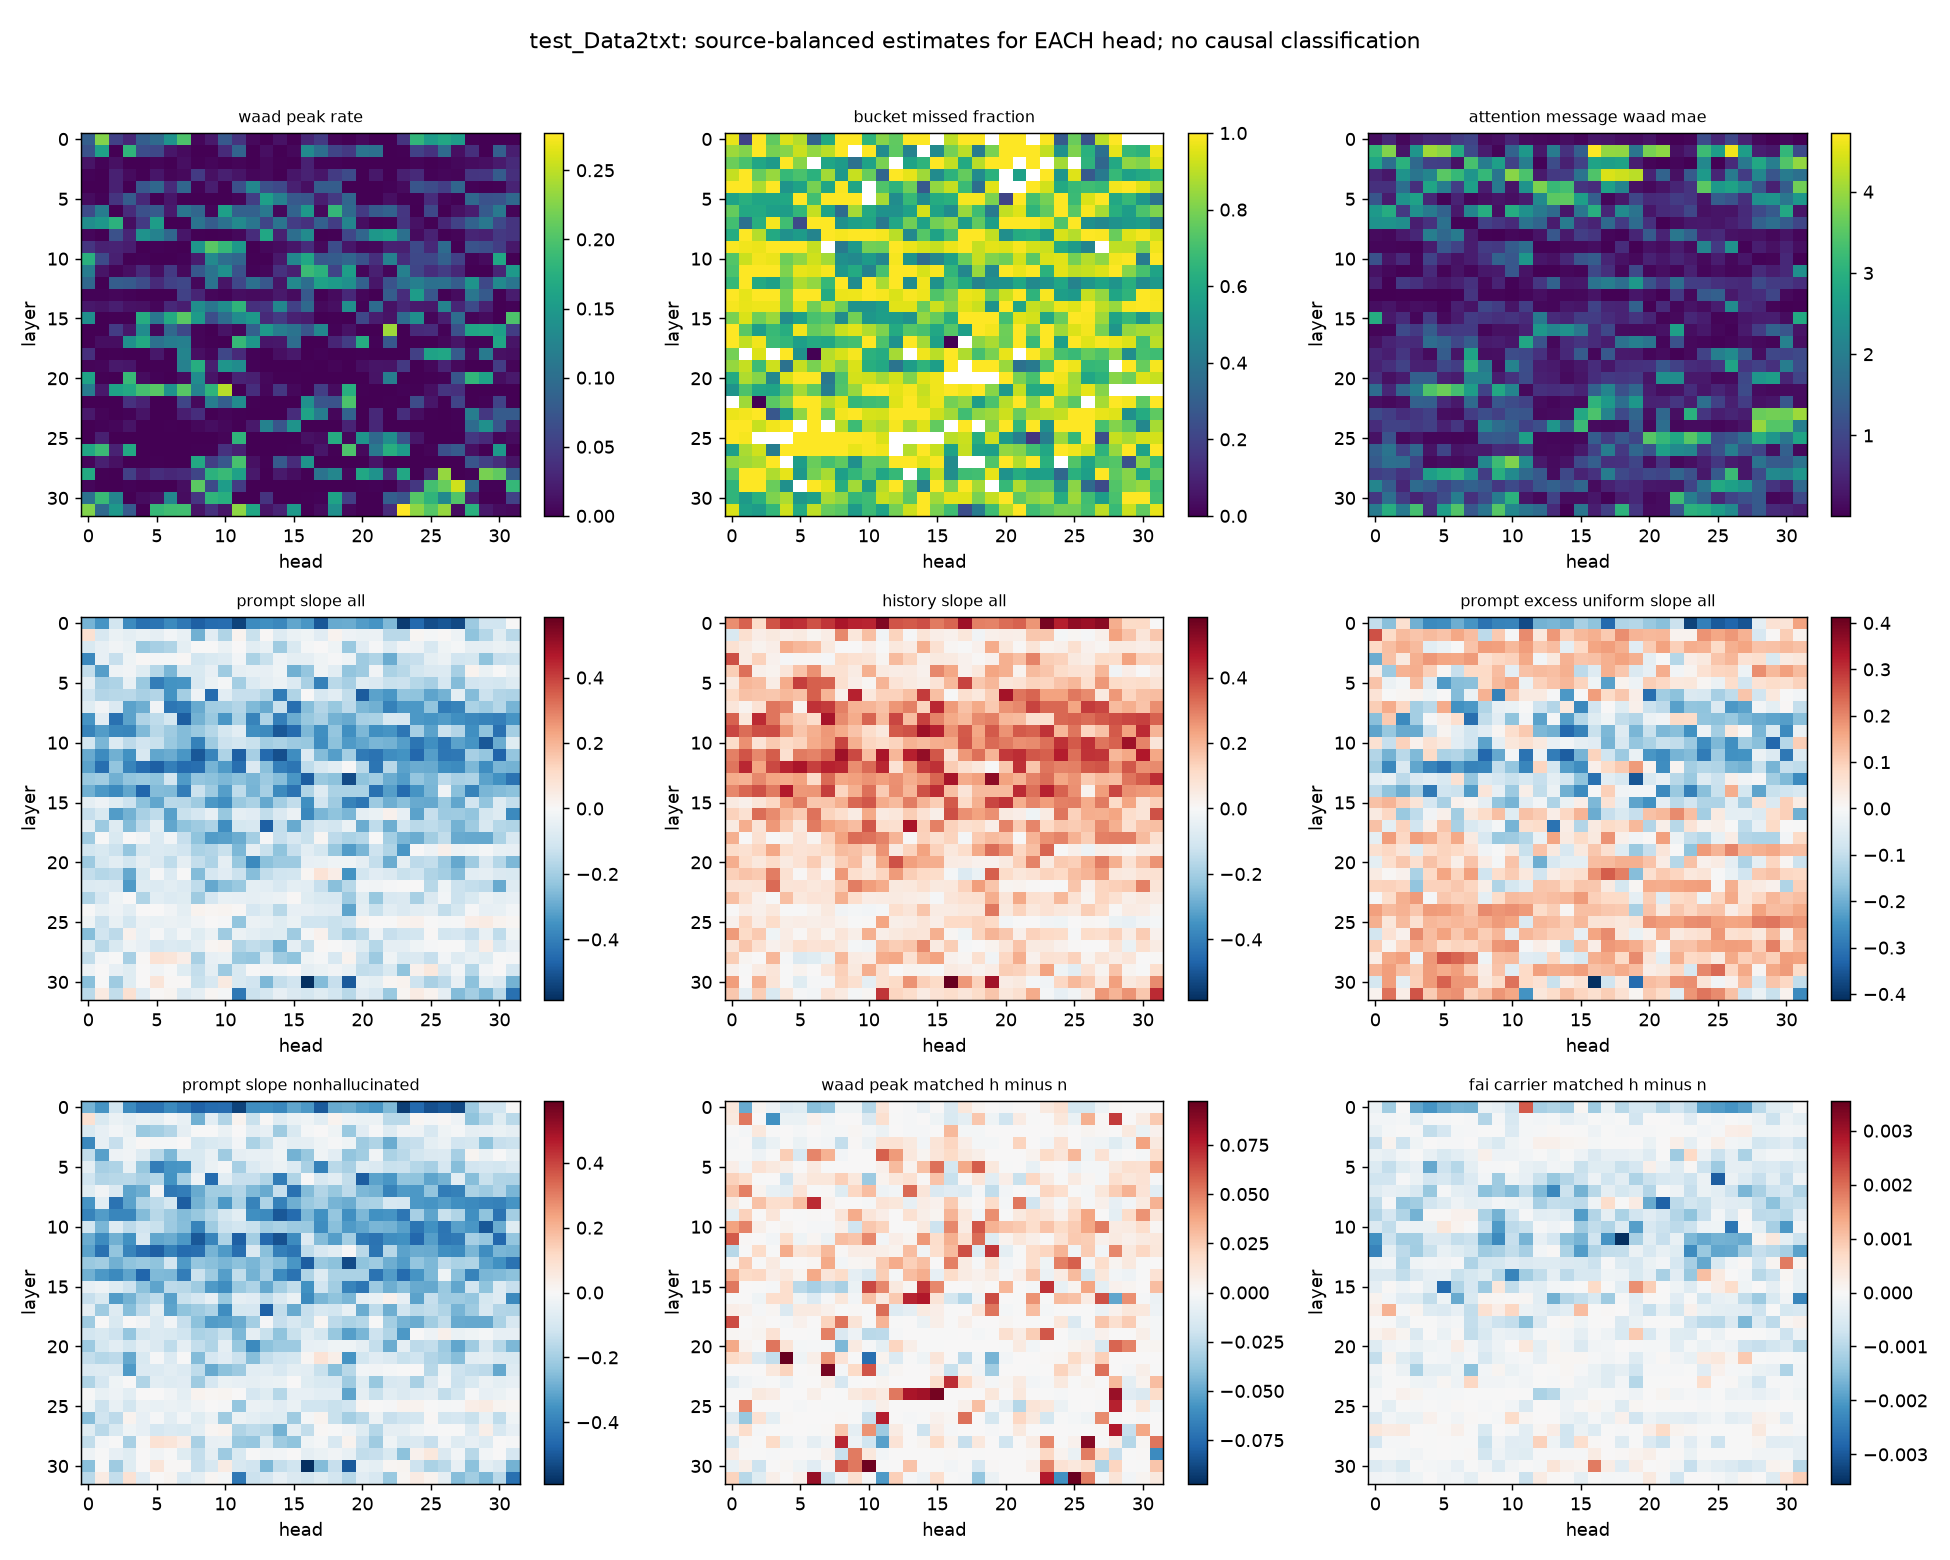

In [1]:
from pathlib import Path
from IPython.display import display, Markdown, Image

out = Path(
    "/share/home/tm902089733300000/a903202310/lys/research/graph/"
    "experiments/reanchor_flow/outputs/attention_rhythm_v2"
)

display(Markdown((out / "summary.md").read_text(encoding="utf-8")))

for name in [
    "population_test_QA.png",
    "head_pairs_test_QA.png",
    "population_test_Summary.png",
    "population_test_Data2txt.png",
]:
    print(name)
    display(Image(filename=str(out / name)))